In [31]:
# Core PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F

# Data + image transforms
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Plotting + utilities
import matplotlib.pyplot as plt
import numpy as np
import os, shutil, random, zipfile, time

# Use the GPU if we have one (much faster). Otherwise the CPU still works.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Make results reproducible
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


Using device: cuda


In [32]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [33]:
ZIP_PATH = "/content/drive/MyDrive/cnn/Wound Image Dataset.zip"

import os
print("Exists:", os.path.exists(ZIP_PATH))

Exists: True


In [35]:
import os, zipfile, shutil, random

RAW_DIR = "/content/Wound_Image_Dataset"
DATASET_DIR = "/content/wound_dataset"
VAL_FRACTION = 0.15
SEED = 42

# --- Step 1: unzip if we don't already have the raw folders ---
if not os.path.isdir(os.path.join(RAW_DIR, "Nomal")):
    if os.path.exists(ZIP_PATH):
        print("Extracting", ZIP_PATH, "...")
        with zipfile.ZipFile(ZIP_PATH) as z:
            z.extractall(RAW_DIR)
    else:
        raise FileNotFoundError(f"Couldn't find '{ZIP_PATH}'.")

def find_folder(root, name):
    for cur, subdirs, _ in os.walk(root):
        if name in subdirs:
            return os.path.join(cur, name)
    return None

normal_src = find_folder(RAW_DIR, "Nomal")
wound_src  = find_folder(RAW_DIR, "wound_main")
assert normal_src and wound_src, "Could not locate Nomal / wound_main folders."

if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

rng = random.Random(SEED)
class_sources = {"normal": normal_src, "wound": wound_src}

for cls, src in class_sources.items():
    files = sorted(f for f in os.listdir(src) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    rng.shuffle(files)
    n_val = int(len(files) * VAL_FRACTION)
    val_files, train_files = files[:n_val], files[n_val:]
    for split, flist in [("train", train_files), ("validation", val_files)]:
        dest = os.path.join(DATASET_DIR, split, cls)
        os.makedirs(dest, exist_ok=True)
        for f in flist:
            shutil.copy(os.path.join(src, f), os.path.join(dest, f))
    print(f"{cls:8s} -> train: {len(train_files):4d}   validation: {len(val_files):4d}")

train_dir = os.path.join(DATASET_DIR, "train")
val_dir   = os.path.join(DATASET_DIR, "validation")
print("\nDone. train_dir =", train_dir, "| val_dir =", val_dir)

normal   -> train: 2344   validation:  413
wound    -> train: 2284   validation:  402

Done. train_dir = /content/wound_dataset/train | val_dir = /content/wound_dataset/validation


In [36]:
IMG_SIZE = 80
BATCH_SIZE = 32

# --- Basic transform: just resize + convert to tensor. No augmentation. ---
basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

# ImageFolder reads images and labels them by their folder name (normal=0, wound=1)
train_ds = datasets.ImageFolder(train_dir, transform=basic_transform)
val_ds   = datasets.ImageFolder(val_dir,   transform=basic_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Classes:", train_ds.classes)                 # ['normal', 'wound']
print("Training images:  ", len(train_ds))
print("Validation images:", len(val_ds))


Classes: ['normal', 'wound']
Training images:   4628
Validation images: 815


### Look at a few images

Always eyeball your data before training.

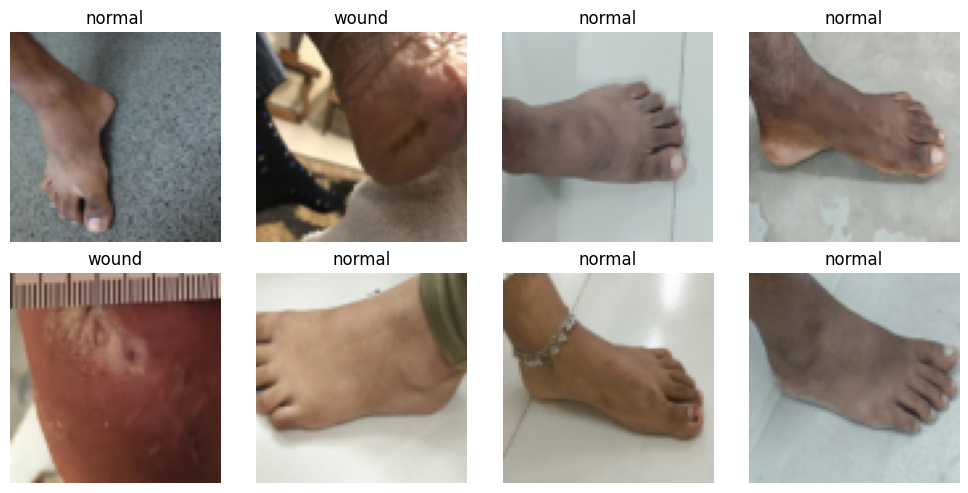

In [37]:
images, labels = next(iter(train_loader))
class_names = train_ds.classes

plt.figure(figsize=(10, 5))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].permute(1, 2, 0))     # tensor [C,H,W] -> matplotlib [H,W,C]
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()


In [38]:
class SimpleCNN(nn.Module):
    def __init__(self, p_dropout=0.0):
        super().__init__()
        # --- Feature extractor: 3 convolution layers ---
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 3 -> 16 filters
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 16 -> 32 filters
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 32 -> 64 filters
        self.pool  = nn.MaxPool2d(2, 2)                           # halves H and W

        # --- Classification head ---
        # After 3 pool operations, an 80x80 image becomes 10x10 with 64 channels
        flat_size = 64 * (IMG_SIZE // 8) * (IMG_SIZE // 8)
        self.dropout = nn.Dropout(p_dropout)
        self.fc1 = nn.Linear(flat_size, 128)
        self.fc2 = nn.Linear(128, 2)   # 2 output scores: [normal, wound]

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 80x80 -> 40x40, 16 channels
        x = self.pool(F.relu(self.conv2(x)))   # 40x40 -> 20x20, 32 channels
        x = self.pool(F.relu(self.conv3(x)))   # 20x20 -> 10x10, 64 channels
        x = torch.flatten(x, 1)                # flatten to a vector per image
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)                        # raw scores (logits) for 2 classes
        return x

model = SimpleCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nTotal trainable parameters: {n_params:,}")


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.0, inplace=False)
  (fc1): Linear(in_features=6400, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)

Total trainable parameters: 843,170


In [39]:
def train_model(model, train_loader, val_loader, epochs=50, lr=0.01):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # We record these each epoch so we can plot curves afterwards
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(epochs):
        t0 = time.time()
        # ---------------- TRAINING ----------------
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        train_loss = running_loss / total
        train_acc = correct / total

        # ---------------- VALIDATION ----------------
        model.eval()
        running_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                running_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += labels.size(0)
        val_loss = running_loss / total
        val_acc = correct / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:2d}/{epochs} | "
              f"train_loss {train_loss:.3f} train_acc {train_acc:.3f} | "
              f"val_loss {val_loss:.3f} val_acc {val_acc:.3f} | "
              f"{time.time()-t0:.1f}s")

    return history


### Run Round 1

Fresh model, dropout **off** (`p_dropout=0.0`), plain (non-augmented) data.

In [40]:
EPOCHS_ROUND1 = 50

model_plain = SimpleCNN(p_dropout=0.0).to(device)
history_plain = train_model(model_plain, train_loader, val_loader, epochs=EPOCHS_ROUND1)


Epoch  1/50 | train_loss 0.412 train_acc 0.829 | val_loss 0.171 val_acc 0.936 | 11.7s
Epoch  2/50 | train_loss 0.131 train_acc 0.950 | val_loss 0.108 val_acc 0.958 | 11.5s
Epoch  3/50 | train_loss 0.120 train_acc 0.957 | val_loss 0.186 val_acc 0.937 | 10.3s
Epoch  4/50 | train_loss 0.103 train_acc 0.963 | val_loss 0.068 val_acc 0.969 | 12.5s
Epoch  5/50 | train_loss 0.079 train_acc 0.974 | val_loss 0.084 val_acc 0.971 | 11.4s
Epoch  6/50 | train_loss 0.074 train_acc 0.974 | val_loss 0.106 val_acc 0.960 | 11.5s
Epoch  7/50 | train_loss 0.095 train_acc 0.966 | val_loss 0.115 val_acc 0.974 | 11.5s
Epoch  8/50 | train_loss 0.064 train_acc 0.980 | val_loss 0.100 val_acc 0.968 | 10.6s
Epoch  9/50 | train_loss 0.076 train_acc 0.975 | val_loss 0.079 val_acc 0.975 | 11.2s
Epoch 10/50 | train_loss 0.047 train_acc 0.983 | val_loss 0.067 val_acc 0.975 | 11.6s
Epoch 11/50 | train_loss 0.046 train_acc 0.984 | val_loss 0.058 val_acc 0.977 | 11.6s
Epoch 12/50 | train_loss 0.037 train_acc 0.986 | val_l

### Plot the loss and accuracy curves

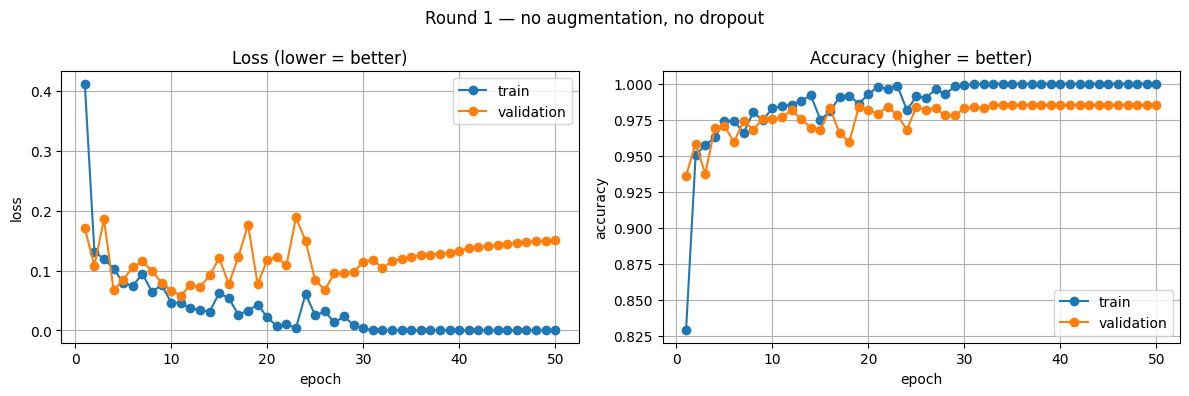

In [41]:
def plot_history(history, title=""):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], "o-", label="train")
    ax1.plot(epochs, history["val_loss"],   "o-", label="validation")
    ax1.set_title("Loss (lower = better)")
    ax1.set_xlabel("epoch"); ax1.set_ylabel("loss"); ax1.legend(); ax1.grid(True)

    ax2.plot(epochs, history["train_acc"], "o-", label="train")
    ax2.plot(epochs, history["val_acc"],   "o-", label="validation")
    ax2.set_title("Accuracy (higher = better)")
    ax2.set_xlabel("epoch"); ax2.set_ylabel("accuracy"); ax2.legend(); ax2.grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history_plain, "Round 1 — no augmentation, no dropout")


In [42]:
# --- Training transform WITH augmentation ---
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),                       # flip left-right
    transforms.RandomRotation(15),                           # small rotations
    transforms.ColorJitter(brightness=0.2, contrast=0.2),    # lighting changes
    transforms.ToTensor(),
])

# --- Validation transform stays basic (no augmentation!) ---
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_ds_aug = datasets.ImageFolder(train_dir, transform=train_transform)
val_ds_clean = datasets.ImageFolder(val_dir,   transform=val_transform)

train_loader_aug  = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader_clean  = DataLoader(val_ds_clean, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


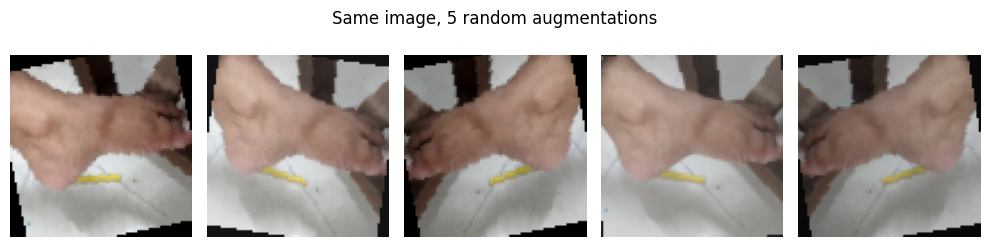

In [43]:
# See the SAME image augmented differently each time
sample_img, _ = train_ds_aug[0]
plt.figure(figsize=(10, 2.5))
for i in range(5):
    aug_img, _ = train_ds_aug[0]     # re-fetching re-applies random transforms
    plt.subplot(1, 5, i + 1)
    plt.imshow(aug_img.permute(1, 2, 0))
    plt.axis("off")
plt.suptitle("Same image, 5 random augmentations")
plt.tight_layout()
plt.show()


Epoch  1/50 | train_loss 0.391 train_acc 0.837 | val_loss 0.115 val_acc 0.963 | 13.9s
Epoch  2/50 | train_loss 0.194 train_acc 0.935 | val_loss 0.273 val_acc 0.864 | 14.1s
Epoch  3/50 | train_loss 0.208 train_acc 0.932 | val_loss 0.124 val_acc 0.950 | 14.3s
Epoch  4/50 | train_loss 0.171 train_acc 0.944 | val_loss 0.078 val_acc 0.974 | 14.3s
Epoch  5/50 | train_loss 0.155 train_acc 0.949 | val_loss 0.099 val_acc 0.978 | 14.3s
Epoch  6/50 | train_loss 0.129 train_acc 0.959 | val_loss 0.114 val_acc 0.969 | 14.1s
Epoch  7/50 | train_loss 0.143 train_acc 0.949 | val_loss 0.072 val_acc 0.969 | 14.1s
Epoch  8/50 | train_loss 0.145 train_acc 0.954 | val_loss 0.065 val_acc 0.975 | 14.1s
Epoch  9/50 | train_loss 0.159 train_acc 0.947 | val_loss 0.239 val_acc 0.918 | 14.2s
Epoch 10/50 | train_loss 0.183 train_acc 0.938 | val_loss 0.076 val_acc 0.973 | 14.2s
Epoch 11/50 | train_loss 0.143 train_acc 0.953 | val_loss 0.064 val_acc 0.977 | 14.1s
Epoch 12/50 | train_loss 0.143 train_acc 0.955 | val_l

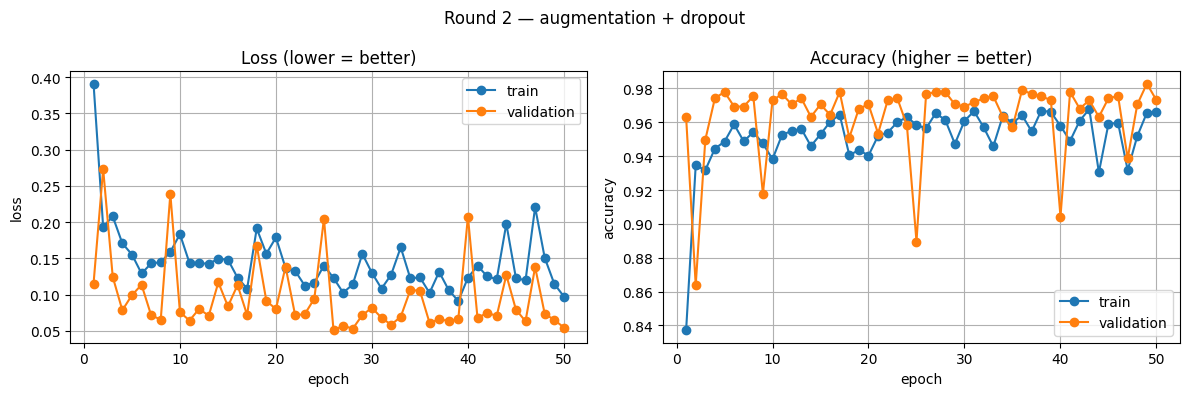

In [44]:
EPOCHS_ROUND2 = 50

# Fresh model, now WITH dropout, trained on augmented data
model_aug = SimpleCNN(p_dropout=0.5).to(device)
history_aug = train_model(model_aug, train_loader_aug, val_loader_clean, epochs=EPOCHS_ROUND2)
plot_history(history_aug, "Round 2 — augmentation + dropout")


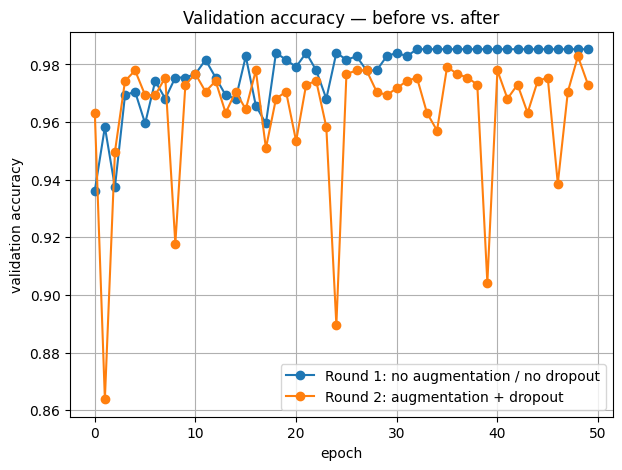

Best val acc   (Round 1): 0.985
Best val acc   (Round 2): 0.983
Final train-val gap (Round 1): 0.015
Final train-val gap (Round 2): -0.007


In [45]:
plt.figure(figsize=(7, 5))
plt.plot(history_plain["val_acc"], "o-", label="Round 1: no augmentation / no dropout")
plt.plot(history_aug["val_acc"],   "o-", label="Round 2: augmentation + dropout")
plt.title("Validation accuracy — before vs. after")
plt.xlabel("epoch"); plt.ylabel("validation accuracy"); plt.legend(); plt.grid(True)
plt.show()

# The train/val GAP is the real overfitting signal — smaller is better.
gap_plain = history_plain["train_acc"][-1] - history_plain["val_acc"][-1]
gap_aug   = history_aug["train_acc"][-1]   - history_aug["val_acc"][-1]

print(f"Best val acc   (Round 1): {max(history_plain['val_acc']):.3f}")
print(f"Best val acc   (Round 2): {max(history_aug['val_acc']):.3f}")
print(f"Final train-val gap (Round 1): {gap_plain:.3f}")
print(f"Final train-val gap (Round 2): {gap_aug:.3f}")


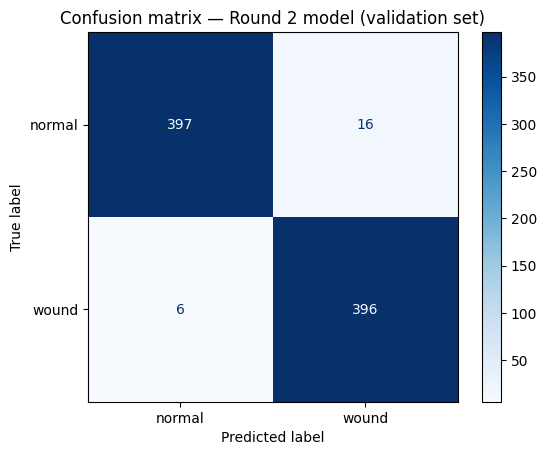

              precision    recall  f1-score   support

      normal       0.99      0.96      0.97       413
       wound       0.96      0.99      0.97       402

    accuracy                           0.97       815
   macro avg       0.97      0.97      0.97       815
weighted avg       0.97      0.97      0.97       815



In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def get_predictions(model, loader):
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            outputs = model(imgs.to(device))
            preds.append(outputs.argmax(1).cpu())
            targets.append(labels)
    return torch.cat(preds).numpy(), torch.cat(targets).numpy()

preds, targets = get_predictions(model_aug, val_loader_clean)
class_names = train_ds.classes   # ['normal', 'wound']

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("Confusion matrix — Round 2 model (validation set)")
plt.show()

print(classification_report(targets, preds, target_names=class_names))


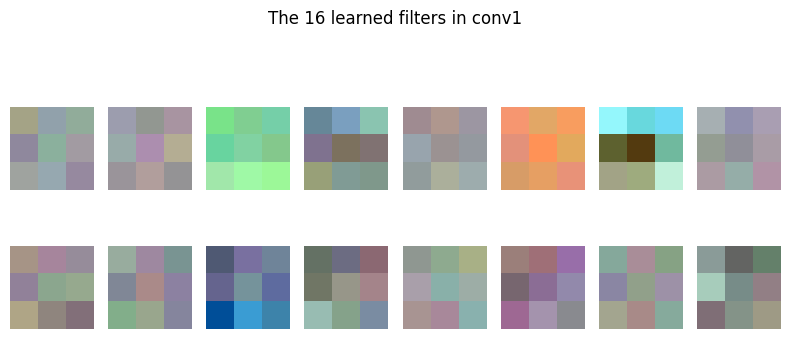

In [47]:
# --- (1) Show the 16 filters of the first conv layer ---
weights = model_aug.conv1.weight.data.clone().cpu()   # shape: [16, 3, 3, 3]

# Scale weights to [0,1] so we can display them as small colour images
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min + 1e-8)

plt.figure(figsize=(8, 4))
for i in range(16):
    plt.subplot(2, 8, i + 1)
    plt.imshow(weights[i].permute(1, 2, 0))
    plt.axis("off")
plt.suptitle("The 16 learned filters in conv1")
plt.tight_layout()
plt.show()


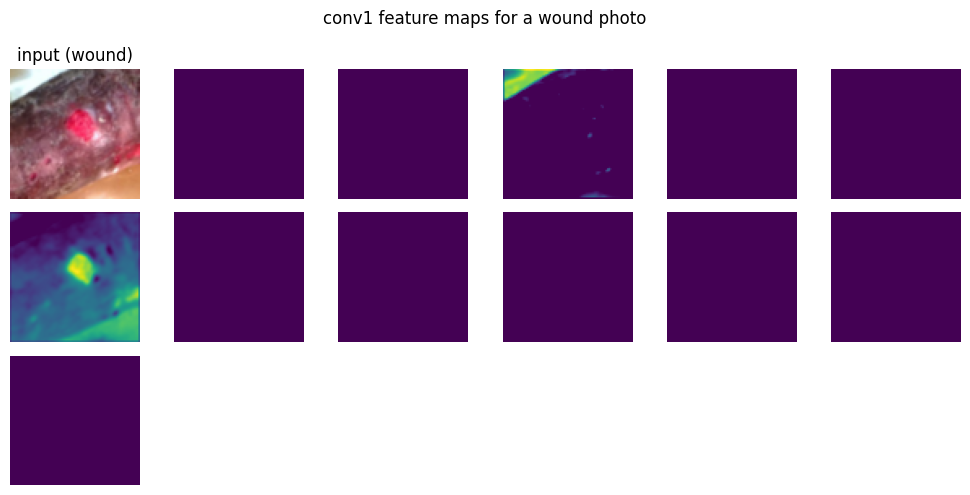

In [48]:
# --- (2) Show feature maps: how conv1 responds to one real wound image ---
# Find a 'wound' example in the validation set
wound_class_idx = class_names.index("wound")
wound_index = next(i for i, (_, lbl) in enumerate(val_ds_clean.samples)
                    if lbl == wound_class_idx)
img, label = val_ds_clean[wound_index]
img_batch = img.unsqueeze(0).to(device)

model_aug.eval()
with torch.no_grad():
    feature_maps = F.relu(model_aug.conv1(img_batch)).cpu()[0]   # shape: [16, 96, 96]

plt.figure(figsize=(10, 5))
plt.subplot(3, 6, 1)
plt.imshow(img.permute(1, 2, 0)); plt.title("input (wound)"); plt.axis("off")
for i in range(12):
    plt.subplot(3, 6, i + 2)
    plt.imshow(feature_maps[i], cmap="viridis")
    plt.axis("off")
plt.suptitle("conv1 feature maps for a wound photo")
plt.tight_layout()
plt.show()
